In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix

from bayes import naive

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bcancer = load_breast_cancer()

X = bcancer.data
y = bcancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)


In [3]:
# My model
model = naive()
model.fit(X_train, y_train)

my_y_pred = model.predict(X_test)

my_accuracy = accuracy_score(y_test, my_y_pred)
print(my_accuracy)

print(f'Accuracy: {my_accuracy * 100 :.2f}%')

0.951048951048951
Accuracy: 95.10%


In [4]:
# sklearn model
model = GaussianNB()

model.fit(X_train, y_train)

sk_y_pred = model.predict(X_test)

sk_accuracy = accuracy_score(y_test, sk_y_pred)
print(sk_accuracy)

print(f'Accuracy: {sk_accuracy * 100 :.2f}%')

0.958041958041958
Accuracy: 95.80%


In [5]:
print("=" * 45)
print(f"  {'Model':<25} {'Accuracy':>10}")
print(f"  {'-'*35}")
print(f"  {'my naive bayes':<25} {my_accuracy:>9.4f}")
print(f"  {'Sklearn naive bayes':<25} {sk_accuracy:>9.4f}")
print("=" * 45)

if my_accuracy == sk_accuracy:
    print("\n  ✅ Implementations match!")

  Model                       Accuracy
  -----------------------------------
  my naive bayes               0.9510
  Sklearn naive bayes          0.9580


In [9]:
# my naive bayes
my_report = classification_report(y_test, my_y_pred, target_names=bcancer.target_names)

# Sklearn naive bayes
sk_report = classification_report(y_test, sk_y_pred, target_names=bcancer.target_names)

print("my naive bayes Classification Report")
print("=" * 50)
print(my_report)

print("Sklearn naive bayes Classification Report")
print("=" * 50)
print(sk_report)

my naive bayes Classification Report
              precision    recall  f1-score   support

   malignant       0.93      0.94      0.94        54
      benign       0.97      0.96      0.96        89

    accuracy                           0.95       143
   macro avg       0.95      0.95      0.95       143
weighted avg       0.95      0.95      0.95       143

Sklearn naive bayes Classification Report
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        54
      benign       0.97      0.97      0.97        89

    accuracy                           0.96       143
   macro avg       0.96      0.96      0.96       143
weighted avg       0.96      0.96      0.96       143



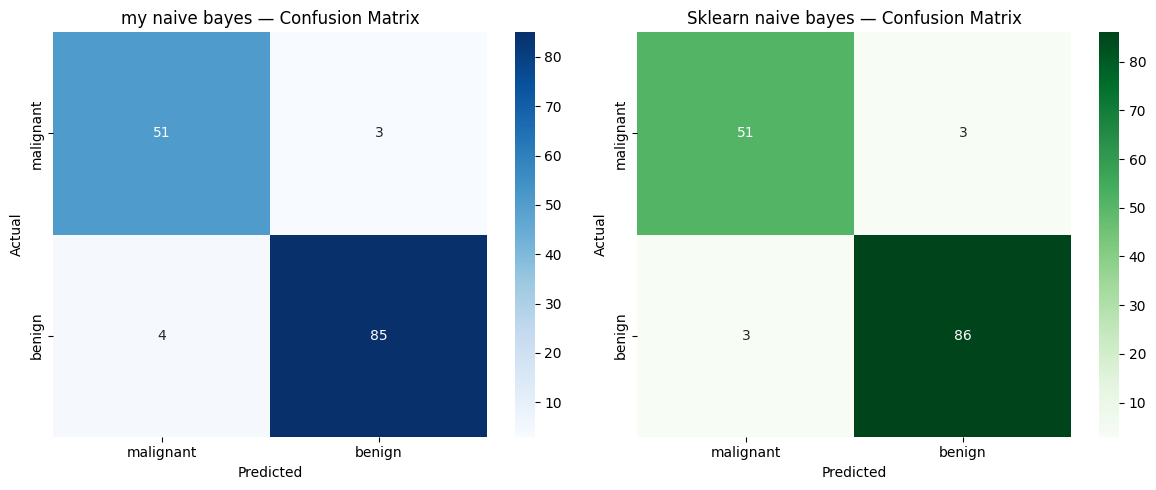

In [8]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# my naive bayes
cm_ours = confusion_matrix(y_test, my_y_pred)
sns.heatmap(
    cm_ours,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=bcancer.target_names,
    yticklabels=bcancer.target_names,
    ax=axes[0]
)
axes[0].set_title('my naive bayes — Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Sklearn naive bayes
cm_sk = confusion_matrix(y_test, sk_y_pred)
sns.heatmap(
    cm_sk,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=bcancer.target_names,
    yticklabels=bcancer.target_names,
    ax=axes[1]
)
axes[1].set_title('Sklearn naive bayes — Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()